
### Analiza statystyczna


In [2]:
import pandas as pd
from os import getcwd
import seaborn as sns
import matplotlib.pyplot as plt
from pennylane.workflow.interfaces import torch
from torch._inductor.codegen.cuda.cutlass_lib_extensions.cutlass_mock_imports.cuda import cuda

import random_forest_model
# print(getcwd())

df = pd.read_parquet('./../../../dataset.parquet')
tasks = ['bioavailability_ma', 'hia_hou', 'pgp_broccatelli', 'bbb_martins',
 'cyp2c9_veith', 'cyp2d6_veith', 'cyp3a4_veith',
 'cyp2c9_substrate_carbonmangels', 'cyp2d6_substrate_carbonmangels',
 'cyp3a4_substrate_carbonmangels', 'hERG_Karim', 'ames', 'dili']
df = df[df['task'].isin(tasks)]

df_wide = df.pivot_table(index='smiles', columns='task', values='label')

In [3]:
print(df['task'].value_counts())
avg_tasks = df.groupby('smiles')['task'].nunique().mean()
print(f"Średnia liczba zadań na smiles: {avg_tasks:.2f}")
presence_mask = df_wide.notna().astype(int)

overlap_matrix = presence_mask.T @ presence_mask

stats_df = df.groupby('task')['label'].agg(['mean', 'count', 'std']).reset_index()
overlap_matrix = overlap_matrix.merge(stats_df, on='task')
overlap_matrix.head()

task
hERG_Karim                        13445
cyp2d6_veith                      13130
cyp3a4_veith                      12328
cyp2c9_veith                      12092
ames                               7278
bbb_martins                        2030
pgp_broccatelli                    1218
cyp3a4_substrate_carbonmangels      670
cyp2c9_substrate_carbonmangels      669
cyp2d6_substrate_carbonmangels      667
bioavailability_ma                  640
hia_hou                             578
dili                                475
Name: count, dtype: int64
Średnia liczba zadań na smiles: 1.63


,task,ames,bbb_martins,bioavailability_ma,cyp2c9_substrate_carbonmangels,cyp2c9_veith,cyp2d6_substrate_carbonmangels,cyp2d6_veith,cyp3a4_substrate_carbonmangels,cyp3a4_veith,dili,hERG_Karim,hia_hou,pgp_broccatelli,mean,count,std
0,ames,7255,173,106,113,110,114,124,112,110,124,58,66,104,0.546029,7278,0.497911
1,bbb_martins,173,1975,293,216,114,217,114,216,104,135,133,90,111,0.764039,2030,0.424702
2,bioavailability_ma,106,293,640,203,81,204,92,202,85,114,141,129,93,0.768750,640,0.421962
3,cyp2c9_substrate_carbonmangels,113,216,203,666,113,660,112,661,103,70,127,127,112,0.210762,669,0.408155
4,cyp2c9_veith,110,114,81,113,12092,113,9750,114,9265,59,69,91,134,0.334519,12092,0.471841


In [4]:
mask = df.groupby('smiles')['task'].transform('nunique') > 1
duplicated_rows = df[df.groupby('smiles')['task'].transform('nunique') > 1].sort_values('smiles')

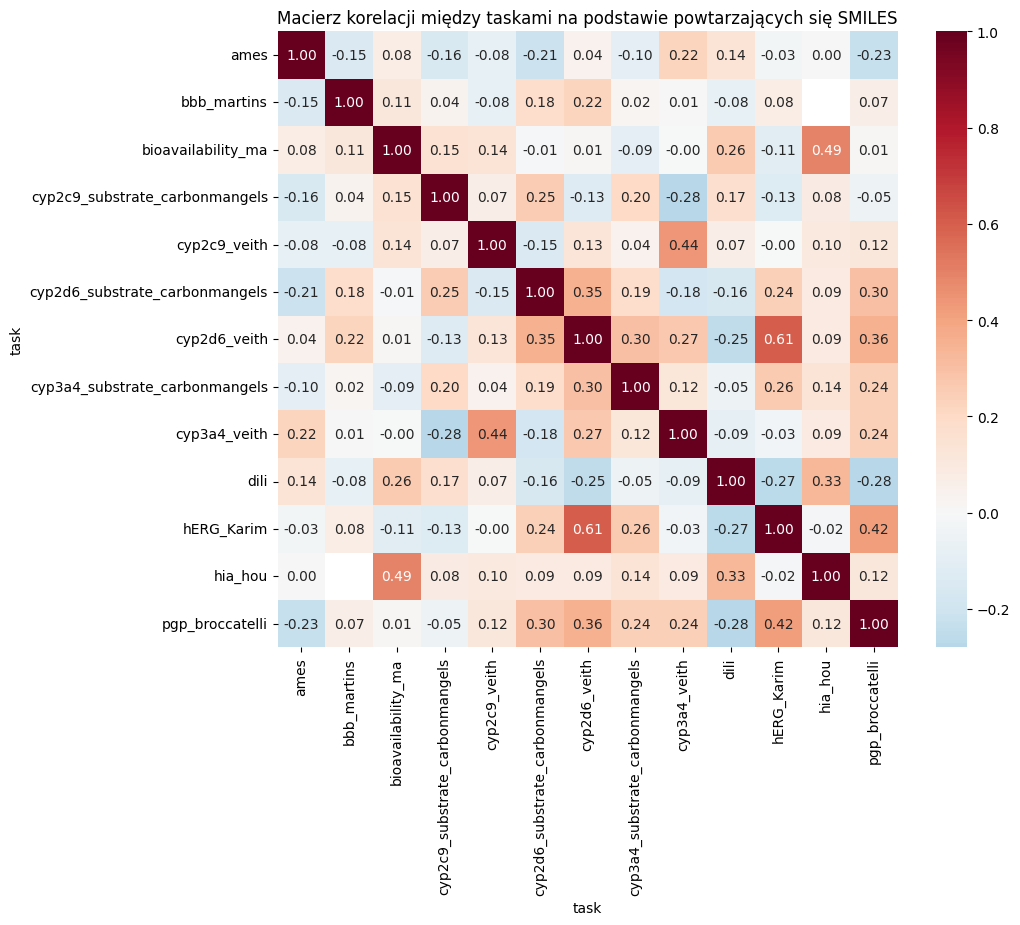

In [5]:
corr_matrix = df_wide.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt=".2f")
plt.title('Macierz korelacji między taskami na podstawie powtarzających się SMILES')
plt.show()

NaN wynika z braku wariancji w części wspólnej hia_hou (absorbcja) i bbb_martins (dystrybucja). W każdym przypadku jeśli badano oba związki to absorbcja wynosiła True.

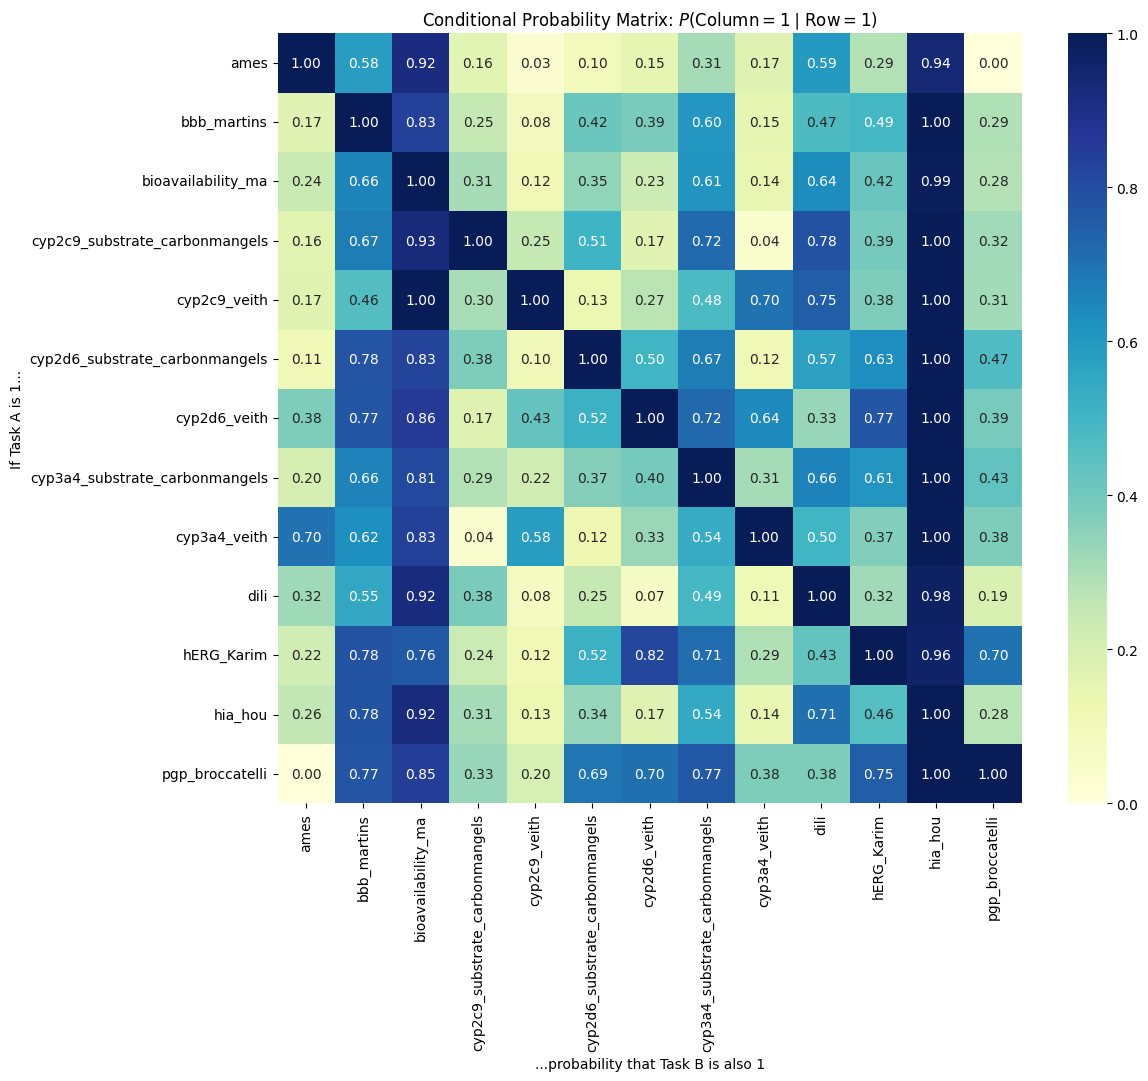

In [6]:
ones_mask = (df_wide == 1).astype(int)
intersection_11 = ones_mask.T @ ones_mask

valid_mask = df_wide.notna().astype(int)
intersection_1x = ones_mask.T @ valid_mask

cond_prob = intersection_11 / intersection_1x

plt.figure(figsize=(12, 10))
sns.heatmap(cond_prob, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Conditional Probability Matrix: $P(\\text{Column}=1 \\mid \\text{Row}=1)$")
plt.ylabel("If Task A is 1...")
plt.xlabel("...probability that Task B is also 1")
plt.show()

### Random Forest

In [7]:
summary_df = random_forest_model.run_single_task_pipeline(df, tasks)
summary_df


--- Top 15 najważniejszych cech dla bioavailability_ma ---
            feature  importance
                qed    0.023362
               TPSA    0.021596
NumValenceElectrons    0.020476
              MolMR    0.019032
          LabuteASA    0.018737
              MolWt    0.017683
   MaxPartialCharge    0.016987
            MolLogP    0.016804
         NumHDonors    0.014577
MaxAbsPartialCharge    0.013753
           BalabanJ    0.013733
     HeavyAtomCount    0.013284
       FractionCSP3    0.012107
            NOCount    0.010613
          NHOHCount    0.010451

--- Top 15 najważniejszych cech dla hia_hou ---
            feature  importance
                qed    0.050851
               TPSA    0.048510
            NOCount    0.031310
          NHOHCount    0.028523
            MolLogP    0.027936
         NumHDonors    0.027043
              MolWt    0.024547
      NumHAcceptors    0.024187
           BalabanJ    0.020982
          LabuteASA    0.020573
              MolMR    0.02

,task,auc,acc,f1
0,bioavailability_ma,0.687865,0.726562,0.834123
1,hia_hou,0.946555,0.905172,0.946341
2,pgp_broccatelli,0.932104,0.868852,0.866667
3,bbb_martins,0.904258,0.864532,0.914463
4,cyp2c9_veith,0.896691,0.817204,0.708827
5,cyp2d6_veith,0.873928,0.872430,0.537931
6,cyp3a4_veith,0.885595,0.797242,0.740933
7,cyp2c9_substrate_carbonmangels,0.671166,0.798507,0.000000
8,cyp2d6_substrate_carbonmangels,0.721695,0.751880,0.400000
9,cyp3a4_substrate_carbonmangels,0.626643,0.589552,0.635762



SOTA results from paper "Quantum Enhanced MTL ...".


In our model used RandomForestClassifier from scikit with 200 estimators.

### MTL model

In [8]:
%load_ext autoreload
%autoreload 2
from mtl_utils import (
    prepare_mtl_data, MTLDataset, MTLNet,
    train_epoch, evaluate, permutation_importance_mtl
)

import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
head_sizes = [64, 128, 256]
epochs = 20
results = {}

X_all, y_all, mask_all, tasks, splits, feat_names = prepare_mtl_data(df)

train_idx = splits == 'train'
val_idx = splits == 'valid'
test_idx = splits == 'test'

train_loader = DataLoader(MTLDataset(X_all[train_idx], y_all[train_idx], mask_all[train_idx]), batch_size=128, shuffle=True)
val_loader = DataLoader(MTLDataset(X_all[val_idx], y_all[val_idx], mask_all[val_idx]), batch_size=128)
test_loader = DataLoader(MTLDataset(X_all[test_idx], y_all[test_idx], mask_all[test_idx]), batch_size=128)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MTLNet(X_all.shape[1], len(tasks)).to(device)
opt = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)


 ROZPOCZYNAMY EKSPERYMENT: head_neurons = 64
Trenowanie MTL (Size: 64)...
Trenowanie 13 modeli STL (Size: 64)...

 ROZPOCZYNAMY EKSPERYMENT: head_neurons = 128
Trenowanie MTL (Size: 128)...
Trenowanie 13 modeli STL (Size: 128)...

 ROZPOCZYNAMY EKSPERYMENT: head_neurons = 256
Trenowanie MTL (Size: 256)...
Trenowanie 13 modeli STL (Size: 256)...


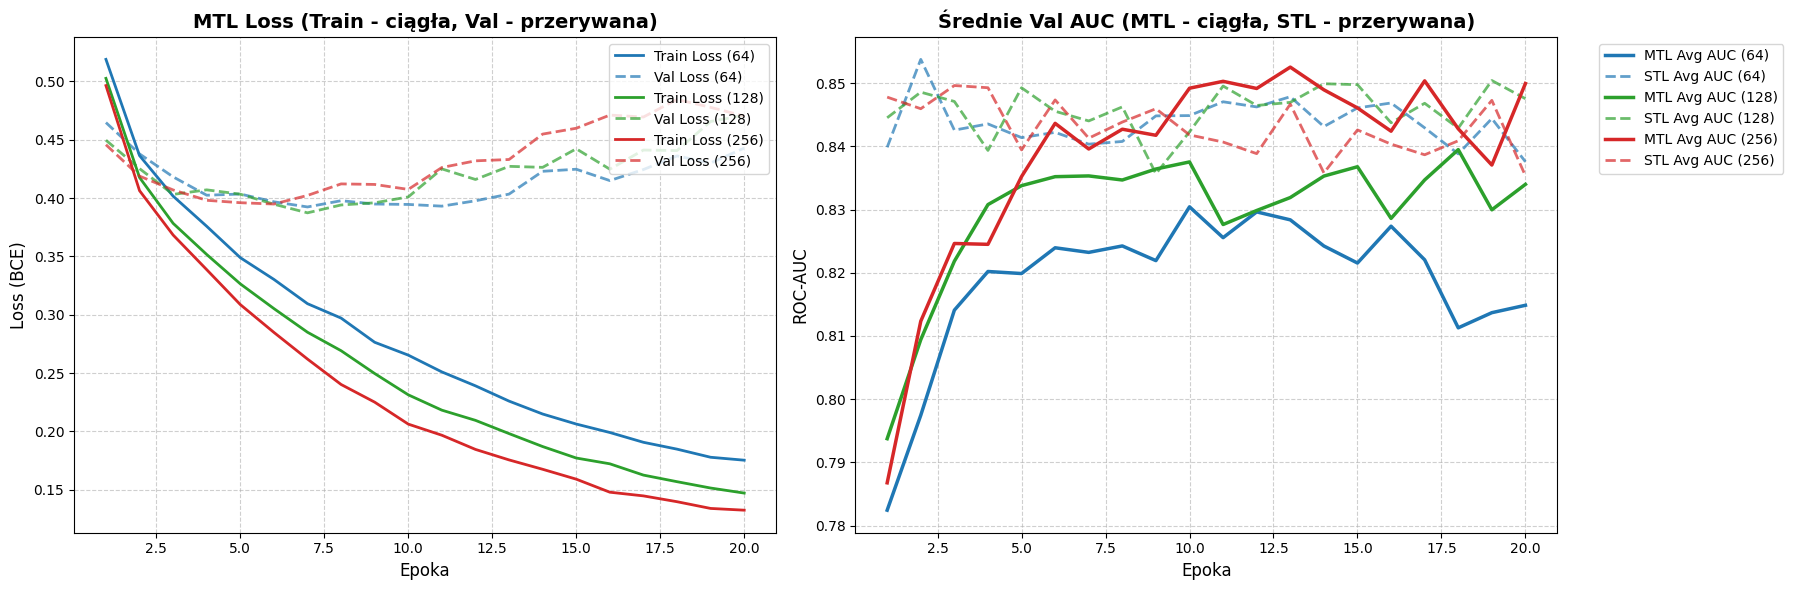

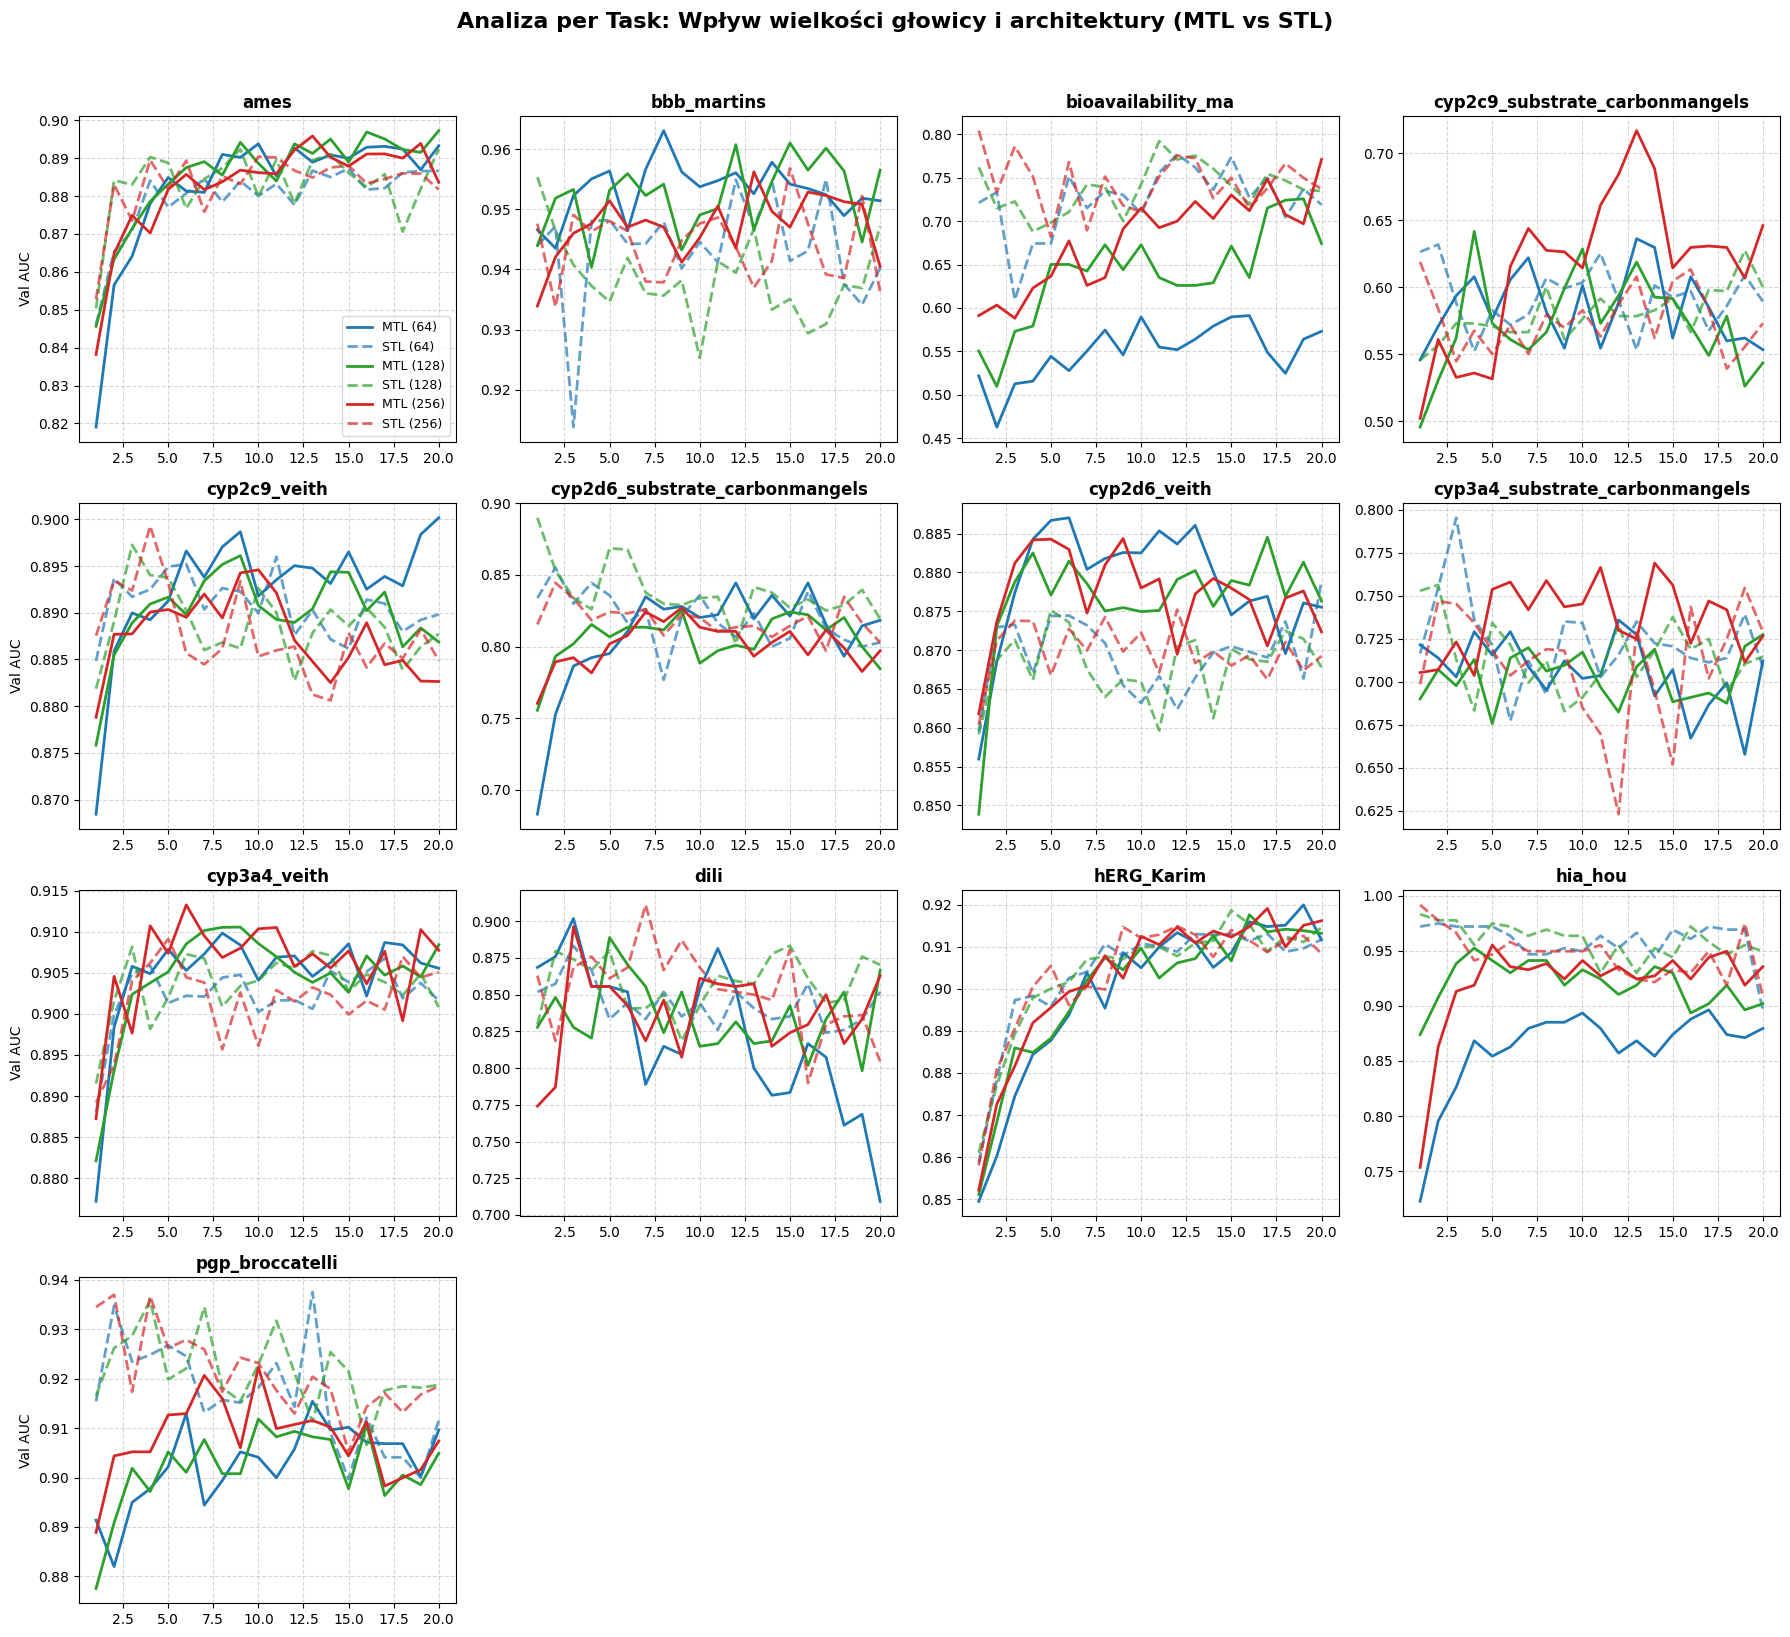

In [9]:
from TODO.zadanie1.michal.mtl_utils import plot_comprehensive_head_experiment

results = {}

for size in head_sizes:
    print(f"\n" + "="*60)
    print(f" ROZPOCZYNAMY EKSPERYMENT: head_neurons = {size}")
    print(f"="*60)

    # Zaktualizowana struktura do trzymania wyników PER TASK
    results[size] = {
        'mtl_history': {'train_loss': [], 'val_loss': [], 'val_auc_avg': [], 'val_aucs_per_task': {t: [] for t in tasks}},
        'stl_history': {'val_auc_avg': [], 'val_aucs_per_task': {t: [] for t in tasks}}
    }

    # =========================================================
    # 1. TRENING MTL DLA DANEGO ROZMIARU
    # =========================================================
    print(f"Trenowanie MTL (Size: {size})...")
    model_mtl = MTLNet(X_all.shape[1], len(tasks), head_neurons=size).to(device)
    opt_mtl = torch.optim.Adam(model_mtl.parameters(), lr=0.001, weight_decay=1e-4)

    for epoch in range(epochs):
        t_loss = train_epoch(model_mtl, train_loader, opt_mtl, device)
        v_loss, v_aucs = evaluate(model_mtl, val_loader, device, tasks)

        results[size]['mtl_history']['train_loss'].append(t_loss)
        results[size]['mtl_history']['val_loss'].append(v_loss) # Zapisujemy Val Loss!
        results[size]['mtl_history']['val_auc_avg'].append(np.nanmean(list(v_aucs.values())))

        # Zapisujemy AUC dla konkretnych zadań z modelu MTL
        for t in tasks:
            results[size]['mtl_history']['val_aucs_per_task'][t].append(v_aucs.get(t, np.nan))

    # =========================================================
    # 2. TRENING STL DLA KAŻDEGO TASKU DLA DANEGO ROZMIARU
    # =========================================================
    print(f"Trenowanie {len(tasks)} modeli STL (Size: {size})...")

    for i, task_name in enumerate(tasks):
        y_train_stl = y_all[train_idx, i].reshape(-1, 1)
        mask_train_stl = mask_all[train_idx, i].reshape(-1, 1)
        y_val_stl = y_all[val_idx, i].reshape(-1, 1)
        mask_val_stl = mask_all[val_idx, i].reshape(-1, 1)

        loader_train_stl = DataLoader(MTLDataset(X_all[train_idx], y_train_stl, mask_train_stl), batch_size=128, shuffle=True)
        loader_val_stl = DataLoader(MTLDataset(X_all[val_idx], y_val_stl, mask_val_stl), batch_size=128)

        model_stl = MTLNet(X_all.shape[1], 1, head_neurons=size).to(device)
        opt_stl = torch.optim.Adam(model_stl.parameters(), lr=0.001, weight_decay=1e-4)

        for epoch in range(epochs):
            _ = train_epoch(model_stl, loader_train_stl, opt_stl, device)
            _, v_aucs_stl = evaluate(model_stl, loader_val_stl, device, [task_name])
            # Zapisujemy historię od razu do głównego słownika
            results[size]['stl_history']['val_aucs_per_task'][task_name].append(v_aucs_stl.get(task_name, np.nan))

    # Obliczanie średniego AUC dla modeli STL w każdej epoce
    for ep in range(epochs):
        avg_ep_auc = np.nanmean([results[size]['stl_history']['val_aucs_per_task'][t][ep] for t in tasks])
        results[size]['stl_history']['val_auc_avg'].append(avg_ep_auc)


# Wywołanie funkcji:
plot_comprehensive_head_experiment(results, head_sizes, tasks, epochs)

## Porównanie wyników

In [10]:
import pandas as pd
import numpy as np
from SOTA_SCORES import SOTA_SCORES

df_rows_best = []

for task in tasks:
    row = {'Task': task}
    for size in head_sizes:
        # Wyciągamy listy z historią AUC dla danego tasku i rozmiaru głowy
        mtl_vals = results[size]['mtl_history']['val_aucs_per_task'][task]
        stl_vals = results[size]['stl_history']['val_aucs_per_task'][task]

        # Używamy np.nanmax, żeby zignorować ewentualne wartości NaN,
        # zabezpieczając przed warningami, gdy cała tablica to NaNy
        row[f'MTL_{size}'] = np.nanmax(mtl_vals) if not np.isnan(mtl_vals).all() else np.nan
        row[f'STL_{size}'] = np.nanmax(stl_vals) if not np.isnan(stl_vals).all() else np.nan

    val = summary_df.loc[summary_df['task'] == task, 'auc']
    row['Random_Forest'] = val.values[0] if not val.empty else np.nan
    row['SOTA'] = SOTA_SCORES[task]
    df_rows_best.append(row)

# Tworzymy DataFrame i ustawiamy Task jako indeks
df_best_val = pd.DataFrame(df_rows_best)
df_best_val.set_index('Task', inplace=True)

# Renderujemy tabelę formatując do 4 miejsc po przecinku
# i automatycznie podświetlamy maksymalną wartość w każdym wierszu (axis=1)
display(
    df_best_val.style
    .format("{:.4f}")
    .highlight_max(axis=1, color='green')
)

,MTL_64,STL_64,MTL_128,STL_128,MTL_256,STL_256,Random_Forest,SOTA
Task,,,,,,,,
ames,0.8938,0.8873,0.8973,0.8924,0.8958,0.8904,0.9176,0.9180
bbb_martins,0.9631,0.9550,0.9610,0.9554,0.9562,0.9568,0.9043,0.9160
bioavailability_ma,0.5913,0.7768,0.7255,0.7919,0.7707,0.8039,0.6879,0.7480
cyp2c9_substrate_carbonmangels,0.6362,0.6318,0.6416,0.6275,0.7168,0.6187,0.6712,0.4410
cyp2c9_veith,0.9002,0.8960,0.8961,0.8973,0.8946,0.8993,0.8967,0.8590
cyp2d6_substrate_carbonmangels,0.8444,0.8551,0.8251,0.8899,0.8271,0.8444,0.7217,0.7360
cyp2d6_veith,0.8870,0.8789,0.8845,0.8751,0.8844,0.8752,0.8739,0.7900
cyp3a4_substrate_carbonmangels,0.7360,0.7954,0.7275,0.7564,0.7691,0.7547,0.6266,0.6620
cyp3a4_veith,0.9098,0.9067,0.9106,0.9081,0.9133,0.9091,0.8856,0.9160


In [11]:
# # Generujesz kod HTML ze stylu
# html_output = df_best_val.style.format("{:.4f}").highlight_max(axis=1, color='green').to_html()
#
# # Zapisujesz do pliku
# with open("./head_size_comparison_results.html", "w") as f:
#     f.write(html_output)